# **Домашнее задание 3. Линейная классификация. Работа с признаками**

### **Оценивание и штрафы**

Кака всегда - каждая из задач имеет «стоимость» (указана в скобках около задачи).

В задании три части:

- Часть 1 (2.5 балла): написание логистической регрессии своими руками
- Часть 2 (5 баллов): различные методы отбора признаков
- Часть 3 (3.5 балла): обучение моделей классификации на текстах

Всего за задание можно получить 11 баллов, но:

**Балл за задание = min{ваш балл, 10}.**

In [ ]:
%pylab inline
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

Populating the interactive namespace from numpy and matplotlib


# **Часть 1. Логистическая регрессия своими руками (2.5 балла)**

## **Задание 1. Реализуйте класс логистической регрессии, обучаемой с помощью:**

**Задание 1.1 (1 балл). Градиентного спуска**

**Задание 1.2 (1 балл). Стохастического градиентного спуска**

До этого вы писали код без ограничений. Здесь же необходимо соблюдать следующие условия:

- Градиентный спуск необходимо записать в векторном виде;
- Циклы средствами python допускается использовать только для итераций градиентного спуска;

**Класс градиентного спуска должен:**
- В качестве критерия останова использовать (одновременно):
  - проверку на евклидову норму разности весов на двух соседних итерациях задаваемого параметром `tolerance`;
  - достижение максимального числа итераций, задаваемого параметром `max_iter`.
- Обладать атрибутом `loss_history`. В нём после вызова метода fit должны содержаться значения функции потерь для всех итераций, начиная с первой (до совершения первого шага по антиградиенту). Данный атрибут необходим, чтобы проследить, что оптимизационный процесс действительно сходится;
- Инициализировать веса случайным образом или нулевым вектором (на ваш выбор).

Полезно [почитать](https://scikit-learn.org/stable/developers/develop.html).

**Шаблон класса описан ниже, вам нужно реализовать каждую из заготовленных функций.**

**ВАЖНО!** Мы заполняем данный шаблон, даже если он нам не нравится. Менять структуру класса и писать по-своему запрещено - за это будут сняты баллы.

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator

class LogReg(BaseEstimator):
    def __init__(self, gd_type='stochastic',
                 tolerance=1e-4, max_iter=1000, w0=None, eta=1e-2):
        """
        gd_type: 'full' or 'stochastic'
        tolerance: for stopping gradient descent
        max_iter: maximum number of steps in gradient descent
        w0: np.array of shape (d) — init weights
        eta: learning rate
        """
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.w = None
        self.eta = eta
        self.loss_history = None # list of loss function values at each training iteration

    def fit(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: self
        """
        self.loss_history = []
        #╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        if self.w0 is not None:
            self.w = np.array(self.w0)
        else:
            self.w = np.random.randn(X.shape[1])
        self.loss_history.append(self.calc_loss(X, y))
        for _ in range(self.max_iter):
            w_old = np.array(self.w)
            if self.gd_type == 'full':
                g = self.calc_gradient(X, y)
            else:
                i = np.random.randint(0, len(X))
                g = self.calc_gradient(X[i:i+1], y[i:i+1])
            self.w -= self.eta * g
            self.loss_history.append(self.calc_loss(X, y))
            if np.linalg.norm(self.w - w_old) < self.tolerance:
                break
        return self


    def predict_proba(self, X):
        if self.w is None:
            raise Exception('Not trained yet')
        #╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        pred_p = 1 / (1 + np.exp(-X.dot(self.w)))
        return pred_p


    def predict(self, X):
        if self.w is None:
            raise Exception('Not trained yet')
        #╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        pred = (self.predict_proba(X) >= 0.5).astype(int)
        return pred

    def calc_gradient(self, X, y):
        """
        X: np.array of shape (ell, d) (ell can be equal to 1 if stochastic)
        y: np.array of shape (ell)
        ---
        output: np.array of shape (d)
        """
        #╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        p = 1 / (1 + np.exp(-X.dot(self.w)))
        grad = X.T.dot(p - y) / X.shape[0]
        return grad

    def calc_loss(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: float
        """
        #╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        p = 1 / (1 + np.exp(-X.dot(self.w)))
        loss = -np.mean(y * np.log(p + 1e-15) + (1 - y) * np.log(1 - p + 1e-15))
        return loss

Теперь проверим работу вашего класса на синтетических данных.

In [ ]:
%pylab inline

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

Populating the interactive namespace from numpy and matplotlib


In [ ]:
X, y = make_classification(
    n_samples=100000, n_features=20, n_informative=10, n_redundant=10,
    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

**Важно:** далее предполагается, что вы используете собственную реализацию логистической регрессии.
Если с написанием класса возникли проблемы, используйте реализацию sklearn, чтобы не терять баллы за остальные задания.

## **Задание 2 (0.5 балла)**

Обучите логистическую регрессию на синтетических данных.

На тестовой части посчитайте ROC-AUC, PR-AUC. Постройте ROC и PR кривые. Проинтерпретируйте результат.

In [ ]:
from sklearn.metrics import roc_auc_score, auc, precision_recall_curve, roc_curve
import matplotlib.pyplot as plt

In [ ]:
model = LogReg()

In [ ]:
model.fit(X_train, y_train)

LogReg()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred_proba = model.predict_proba(X_test)

In [ ]:
ROC_AUC = roc_auc_score(y_test, y_pred_proba)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
PR_AUC = auc(recall, precision)
print(f'ROC-AUC - {ROC_AUC}, PR-AUC - {PR_AUC}')

ROC-AUC - 0.7453270544545185, PR-AUC - 0.7444773283030239


In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

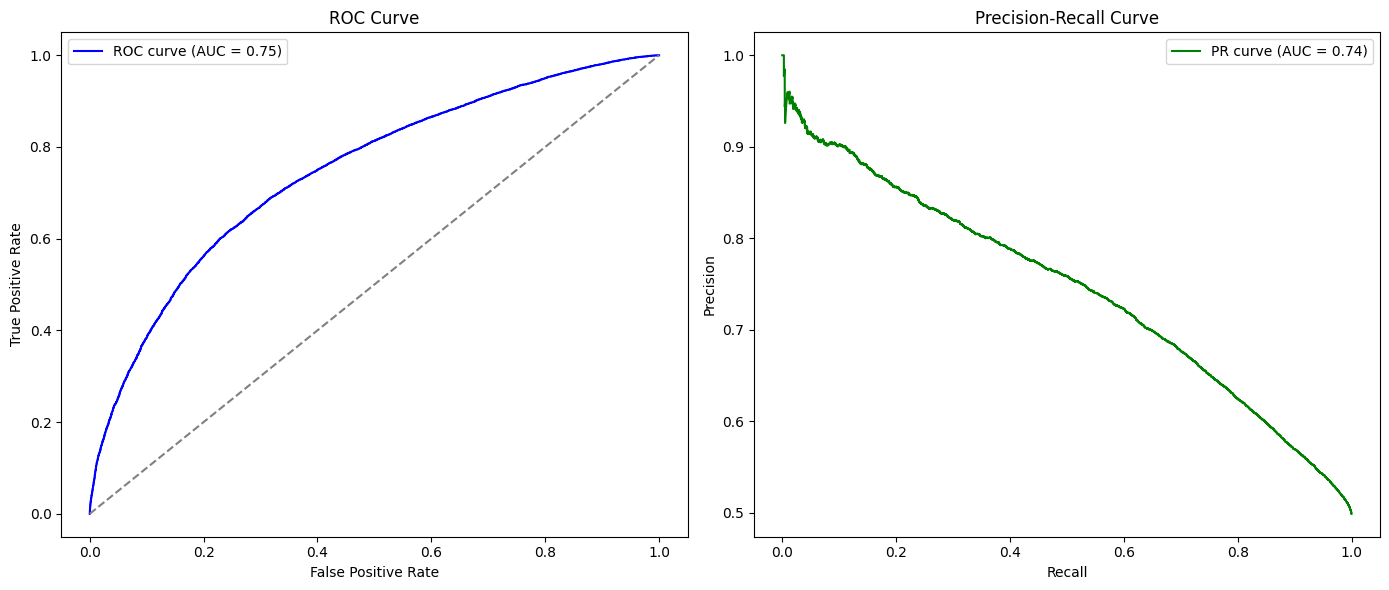

In [ ]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {ROC_AUC:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', label=f'PR curve (AUC = {PR_AUC:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()

По ROC-AUC: с каждым запуском он прыгает от 0.3 до 0.7
Форма PR кривой получилась странная  
Видно что модель не сходится, нужно попробовать обучить ее с полным градиентным спуском

In [ ]:
model_2 = LogReg(gd_type='full')
model_2.fit(X_train, y_train)
y_pred_proba_2 = model_2.predict_proba(X_test)

ROC_AUC_2 = roc_auc_score(y_test, y_pred_proba_2)
precision_2, recall_2, _ = precision_recall_curve(y_test, y_pred_proba_2)
PR_AUC_2 = auc(recall_2, precision_2)
print(f'ROC-AUC - {ROC_AUC_2}, PR-AUC - {PR_AUC_2}')

ROC-AUC - 0.9220241884574584, PR-AUC - 0.9179993637531674


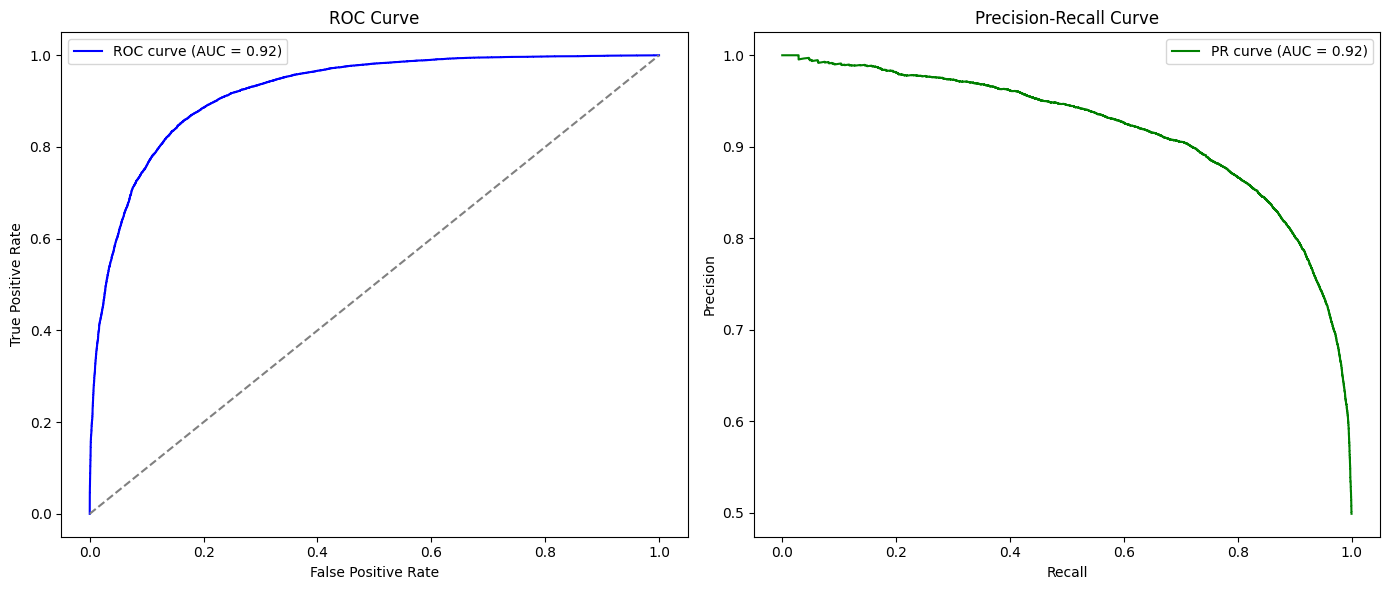

In [ ]:
fpr_2, tpr_2, _ = roc_curve(y_test, y_pred_proba_2)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(fpr_2, tpr_2, color='blue', label=f'ROC curve (AUC = {ROC_AUC_2:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall_2, precision_2, color='green', label=f'PR curve (AUC = {PR_AUC_2:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()

Тут все намного лучше

# **Часть 2. Отбор признаков (5 баллов)**

Перейдём к еще одной важной части процесса работы с данными — отбору признаков. Он нужен в следующих случаях:
- Мы хотим сократить время вычислений;
- Мы хотим избежать переобучения;
- Мы хотим попытаться улучшить качество модели за счет уменьшения признакового пространства;

В этой части мы попробуем применить несколько подходов для отбора признаков и оценим, как они влияют на качество модели и сколько времени занимают.

**Данные** \

Будем использовать датасет [об обращениях клиентов по страховым случаям](https://www.kaggle.com/competitions/porto-seguro-safe-driver-prediction/data?select=train.csv). Скачайте его с Kaggle (файл `train.csv`).

Задача представляет собой бинарную классификациюю — воспользуется ли клиент страховкой на авто в ближайший год.

In [ ]:
# PATH_TO_DATASET = ...

data = pd.read_csv('train.csv.zip', index_col=0)
target = data.target.values

data = data.drop('target', axis=1)

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=124)

In [ ]:
X_train.shape, X_test.shape

((476169, 57), (119043, 57))

In [ ]:
data.columns

Index(['ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03', 'ps_ind_04_cat',
       'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin',
       'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin',
       'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15', 'ps_ind_16_bin',
       'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03',
       'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat',
       'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat',
       'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat', 'ps_car_11',
       'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_calc_01',
       'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06',
       'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11',
       'ps_calc_12', 'ps_calc_13', 'ps_calc_14', 'ps_calc_15_bin',
       'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin',
       'ps_calc_20_bin'],
      dtype='obj

### **Задание 3. (0.25 балла)**

Прежде всего — в данных много категориальных признаков.

- Закодируйте их с помощью one-hot кодирования. Категориальные признаки отмечены постфиксом `cat`;
- Исходные колонки с категориальными признаками удалите;
- Зафиксируйте, сколько признаков получилось;

In [ ]:
# from sklearn.preprocessing import OneHotEncoder

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
columns_for_ohe = [x for x in data.columns if x.endswith('cat')]

In [ ]:
X_train_enc = pd.get_dummies(X_train, columns=columns_for_ohe, dtype=float)
X_train_enc.head()

,ps_ind_01,ps_ind_03,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,...,ps_car_11_cat_95,ps_car_11_cat_96,ps_car_11_cat_97,ps_car_11_cat_98,ps_car_11_cat_99,ps_car_11_cat_100,ps_car_11_cat_101,ps_car_11_cat_102,ps_car_11_cat_103,ps_car_11_cat_104
id,,,,,,,,,,,,,,,,,,,,,
381341,1,8,0,0,1,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1327969,2,2,0,0,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
601794,0,2,1,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
632925,6,11,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74864,3,5,0,0,1,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_test_enc = pd.get_dummies(X_test, columns=columns_for_ohe, dtype=float)
X_test_enc.head()

,ps_ind_01,ps_ind_03,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,...,ps_car_11_cat_95,ps_car_11_cat_96,ps_car_11_cat_97,ps_car_11_cat_98,ps_car_11_cat_99,ps_car_11_cat_100,ps_car_11_cat_101,ps_car_11_cat_102,ps_car_11_cat_103,ps_car_11_cat_104
id,,,,,,,,,,,,,,,,,,,,,
1149576,4,0,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1022505,0,5,1,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
451220,0,5,1,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
387700,4,9,0,0,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
835896,0,1,0,0,1,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_train_enc.shape, X_test_enc.shape

((476169, 227), (119043, 227))

### **Задание 4 (1 балл)**

Обучим несколько моделей, перечисленных ниже. В качестве метрики будем использовать ROC-AUC.

**Задание 4.1**

- Обучите модель логистической регрессии. Замерьте скорость обучения модели
- Обучите метод опорных векторов
- Обучите метод k ближайших соседей
- Посчитайте качество моделей (ROC-AUC) на тестовой выборке

**Задание 4.2**

Для каждой из трех моделей (логистическая регрессия, SVM, KNN) подберите при помощи GridSearchCV на тренировочных данных оптимальные гиперпараметры:
- Для логистической регрессии: C, class_weight
- Для SVM: C, kernel, class_weight
- Для KNN: n_neighbors, weights

Затем посчитайте качество моделей на тестовой выборке.

В заданиях 4.1 и 4.2 замеряйте время обучения моделей.


In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from time import time
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
start = time()
model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train_enc, y_train)
end = time()
pred_proba_log = model_log.predict_proba(X_test_enc)
model_log_auc = roc_auc_score(y_test, pred_proba_log[:, 1])
print(f"Время обучения логистической регрессии: {end - start}, ROC-AUC: {model_log_auc}")

Время обучения логистической регрессии: 70.04756546020508, ROC-AUC: 0.6377835441252082


In [ ]:
X_train_enc_short =  X_train_enc[:20000]
y_train_short = y_train[:20000]

X_test_enc_short = X_test_enc[:5000]
y_test_short = y_test[:5000]

In [ ]:
# на полном датасете я результата не дождалась, поэтому уменьшила его до 20000
start = time()
model_svc = SVC(probability=True)
model_svc.fit(X_train_enc_short, y_train_short)
end = time()
pred_proba_svc = model_svc.predict_proba(X_test_enc_short)
model_svc_auc = roc_auc_score(y_test_short, pred_proba_svc[:, 1])
print(f"Время обучения методом опорных векторов: {end - start}, ROC-AUC: {model_svc_auc}")

Время обучения методом опорных векторов: 212.4694526195526, ROC-AUC: 0.533260197993851


In [ ]:
start = time()
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_enc, y_train)
end = time()
pred_proba_knn = model_knn.predict_proba(X_test_enc)
model_knn_auc = roc_auc_score(y_test, pred_proba_knn[:, 1])
print(f"Время обучения методом k ближайших соседей: {end - start}, ROC-AUC: {model_knn_auc}")

Время обучения методом k ближайших соседей: 1.442577600479126, ROC-AUC: 0.5116073961247015


Дольше всего обучалась модель SVC несмотря на то что для нее я использовала урезанный датасет.

In [ ]:
params_log = {
    'C': [0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}
start = time()
GSVC_log = GridSearchCV(LogisticRegression(max_iter=1000), params_log, cv=3, scoring='roc_auc')
GSVC_log.fit(X_train_enc, y_train)
end = time()
best_log = GSVC_log.best_estimator_
print(f"Время обучения при помощи GridSearchCV логистической регрессии: {end - start}, Лучшие параметры: {best_log}")

Время обучения при помощи GridSearchCV логистической регрессии: 2295.362187385559, ROC-AUC: LogisticRegression(C=0.1, max_iter=1000)


In [ ]:
params_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'sigmoid'],
    'class_weight': [None, 'balanced']
}
start = time()
GSVC_svc = GridSearchCV(SVC(probability=True), params_svc, cv=2, scoring='roc_auc')
GSVC_svc.fit(X_train_enc_short, y_train_short)
end = time()
best_svc = GSVC_svc.best_estimator_
print(f"Время обучения при помощи GridSearchCV методом опорных векторов: {end - start}, Лучшие параметры: {best_svc}")

Время обучения при помощи GridSearchCV методом опорных векторов: 2640.439765691757, Лучшие параметры: SVC(C=1, class_weight='balanced', probability=True)


In [ ]:
params_knn = {
    'n_neighbors': [3, 6, 9],
    'weights': ['uniform', 'distance']
}
start = time()
GSVC_knn = GridSearchCV(KNeighborsClassifier(), params_knn, cv=3, scoring='roc_auc')
GSVC_knn.fit(X_train_enc_short, y_train_short)
end = time()
best_knn = GSVC_knn.best_estimator_
print(f"Время обучения при помощи GridSearchCV методом k ближайших соседей: {end - start}, Лучшие параметры: {best_knn}")

Время обучения при помощи GridSearchCV методом k ближайших соседей: 39.0303750038147, Лучшие параметры: KNeighborsClassifier(n_neighbors=9)


Дольше всех опять SVM

### **Встроенные методы**

**Заметим, что:**

- Время обучения моделей отличается между собой.
- Несмотря на то, что признаков много, качество модели не очень хорошее.


Попробуем решить проблемы — улучшить качество и при этом сократить пространство признаков и, соответственно, время обучения моделей.



**Отбор признаков встроеным методом.**

Начнём с отбора признаков с помощью линейной модели. Делая это, мы используем факт:
> веса линейной модели отражают  вклад каждого признака в предсказание модели, а значит, модуль этого вклада можно интерпретировать как важность признаков.

Такой метод отбора называются встроенным в модель методом, так как он заложен в особенности модели.

**Важно:** применение этого подхода требует машстабирования признаков (подумайте, почему). Вы можете использовать приведение к стандартному нормальному распределению (`StandardScaler`) с параметрами или MinMax преобразование (`MinMaxScaler`).

### **Задание 5 (0.75 балла)**

Оставьте 150 признаков с наибольшими по модулю весами после обучения логистической регрессии.

- Замерьте скорость такого отбора признаков. (0.2 балла)

- Обучите логистическую регрессию на исходных признаках. Из них оставьте 150 лучших (с наибольшими по модулю весами).
- Масштабируйте данные — все, кроме категориальных и бинарных признаков. Зафиксируйте, сколько признаков пришлось масштабировать. (0.25 балла)
- Обучите новую модель на 150 признаках и оцените её качество. (0.15 балла)




In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
model_log

LogisticRegression(max_iter=1000)

In [ ]:
start = time()
coefficients = model_log.coef_.flatten()
sorted_features = np.argsort(np.abs(coefficients))[-150:]
top_150 = X_train_enc.columns[sorted_features]

X_train_enc_top150 = X_train_enc[top_150]
X_test_enc_top150 = X_test_enc[top_150]
end = time()
print(f'Время отбора 150 лучших фичей - {end - start}')

Время отбора 150 лучших фичей - 1.3554015159606934


In [ ]:
col_for_scale = [col for col in X_train_enc_top150.columns if "cat" not in col and "bin" not in col]

In [ ]:
scaler = StandardScaler()
X_train_enc_scaled = X_train_enc_top150.copy()
X_test_enc_scaled = X_test_enc_top150.copy()
X_train_enc_scaled[col_for_scale] = scaler.fit_transform(X_train_enc_top150[col_for_scale])
X_test_enc_scaled[col_for_scale] = scaler.transform(X_test_enc_top150[col_for_scale])

In [ ]:
print(f'Количество масштабируемых признаков - {len(col_for_scale)}')

Количество масштабируемых признаков - 6


In [ ]:
X_train_enc_scaled.columns

Index(['ps_ind_05_cat_6', 'ps_car_11_cat_92', 'ps_car_11_cat_24',
       'ps_car_11_cat_87', 'ps_car_11_cat_59', 'ps_car_11_cat_76',
       'ps_car_11_cat_28', 'ps_car_15', 'ps_car_11_cat_38', 'ps_car_11_cat_71',
       ...
       'ps_car_11_cat_50', 'ps_ind_02_cat_-1', 'ps_car_03_cat_-1',
       'ps_car_01_cat_7', 'ps_ind_04_cat_1', 'ps_car_07_cat_-1',
       'ps_ind_05_cat_-1', 'ps_ind_04_cat_0', 'ps_ind_05_cat_0', 'ps_car_13'],
      dtype='object', length=150)

In [ ]:
model_log_150 = LogisticRegression(max_iter=1000)
model_log_150.fit(X_train_enc_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
pred_proba_log_150 = model_log_150.predict_proba(X_test_enc_scaled)
model_log_150_auc = roc_auc_score(y_test, pred_proba_log_150[:, 1])
print(f"ROC-AUC: {model_log_150_auc}")

ROC-AUC: 0.6358950107178989


### **Бонус (0.25 балла)**

Попробуйте реализовать итеративный отбор признаков, а именно:

1) Сначала отобрать около 200 признаков (действуя как в задании выше)

2) Потом повторить процедуру для отбора 150 признаков из 200 (снова действуя как в задании выше)

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
def select_features(model, data, num_feat):
  coefficients = model.coef_.flatten()
  sorted_features = np.argsort(np.abs(coefficients))[-num_feat:]
  top_150 = data.columns[sorted_features]
  result = data[top_150]
  return result

In [ ]:
X_train_enc_200 = select_features(model_log, X_train_enc, 200)
X_test_enc_200 = select_features(model_log, X_test_enc, 200)

In [ ]:
X_train_enc_200.shape

(476169, 200)

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train_enc_200, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
pred_proba = model.predict_proba(X_test_enc_200)
model_auc = roc_auc_score(y_test, pred_proba[:, 1])
model_auc

0.6382393091600309

In [ ]:
X_train_enc_150 = select_features(model_log, X_train_enc, 150)
X_test_enc_150 = select_features(model_log, X_test_enc, 150)

In [ ]:
X_train_enc_150.shape

(476169, 150)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_enc_150, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
pred_proba = model.predict_proba(X_test_enc_150)
model_auc = roc_auc_score(y_test, pred_proba[:, 1])
model_auc

0.6361050553202112

### **Задание 6 (0.5 балла)**

Также можно задать отбор признаков, используя другия свойства модели. Вспомним, что L1-регуляризация тоже умеет отбирать признаки.

- Обучите модель на исходных данных. Подберите по сетке (GridSearch) наилучшее значение коэффициента регуляризации C. (0.1 балла)

- Посмотрите сколько признаков отобрала модель с найденным оптимальным C?
  - Сначала посчитайте только число ненулевых весов
  - Затем посчитайте число весов, которые после округления до двух знаков после запятой не равны нулю (0.25 балла)

Удалось ли отобрать 150 признаков за 1 шаг? (0.05 балла)

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:
params = {"C": [0.01, 0.1, 1, 10, 50, 100]}
model_log_l1 = LogisticRegression(penalty="l1", solver="liblinear")
GSCV_l1 = GridSearchCV(model_log_l1, params, scoring="roc_auc", cv=5)
GSCV_l1.fit(X_train_enc, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(penalty='l1', solver='liblinear'),
             param_grid={'C': [0.01, 0.1, 1, 10, 50, 100]}, scoring='roc_auc')

In [ ]:
best_l1 = GSCV_l1.best_estimator_
best_l1

LogisticRegression(C=0.1, penalty='l1', solver='liblinear')

In [ ]:
best_param = GSCV_l1.best_params_['C']
best_param

0.1

In [ ]:
features_not0 = np.sum(np.round(best_l1.coef_, 2) != 0)
features_not0

120

Удалось ли отобрать 150 признаков за 1 шаг? Не удалось, отобралось 120

### **Методы фильтрации**

Также можно отбирать признаки, применяя методы математической статистики. А именно, в нашем случае, через подсчёт некоторой функции для каждого признака. На основании значений этой функции (она называется *статистикой*) мы можем оставлять наиболее важные признаки. Методы этого семейства называют *фильтрационными* или *filter methods*.

**Что проверяем:**

Равны ли математические ожидания (то есть выборочные средние) распределений признака для двух разных классов? Если они различаются, значит и сами распределения разные. И можно сделать вывод, что по этому признаку модель сможет отличить один класс от другого. А если распределения неотличимы и значение статистики маленькое, то и признак бесполезен.


Для проверки будем считать t-статистику:

$$t(x) = \frac{|\mu_+ - \mu_-|}{\sqrt{\frac{n_+ s^2_+ + n_- s^2_-}{n_+ + n_-}}},$$

где $\mu$, $s$, $n$ соответственно среднее, среднеквадратичное отклонение и количество объектов каждого из классов.

**Примечание:** Если у вас была данная тема на курсе по математической статистике, то вы без труда узнаете статистику гипотезы о разности средних при неизвестных дисперсиях.

Хотя мы и не используем статистическое тестирование явно, предпосылки о том, что наблюдения независимы, одинаково распределены и $n$ велико, должны соблюдаться, иначе статистика не имеет смысла. Но у нас большая выборка, поэтому они выполняются.

Для отбора признаков по t-статистике мы возьмём признаки с наибольшим значением статистики.

### **Задание 7 (1 балла)**

-  Масштабируйте признаки исходного датасета — все, кроме категориальных и бинарных.
- Выделите непрерывные признаки (те, которые масштабировали)
- Посчитайте значения t-статистики. Оставьте ***половину*** признаков с наибольшим значением статистики, объедините их с категориальными и бинарными.
- Обучите модель логистической регрессии и замерьте качество.

Не забудьте замерить скорость отбора признаков в этом случаев.

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
col_for_scale = [col for col in X_train_enc.columns if "cat" not in col and "bin" not in col]
scaler = StandardScaler()
X_train_enc_scaled = X_train_enc.copy()
X_test_enc_scaled = X_test_enc.copy()
X_train_enc_scaled[col_for_scale] = scaler.fit_transform(X_train_enc[col_for_scale])
X_test_enc_scaled[col_for_scale] = scaler.transform(X_test_enc[col_for_scale])

In [ ]:
start = time()
t = []
for feature in col_for_scale:
    class_plus = X_train_enc[y_train == 1][feature]
    class_minus = X_train_enc[y_train == 0][feature]

    n_plus, n_minus = len(class_plus), len(class_minus)
    mu_plus, mu_minus = class_plus.mean(), class_minus.mean()
    s_plus, s_minus = class_plus.std(), class_minus.std()

    t_stat = abs(mu_plus - mu_minus) / np.sqrt((s_plus**2 / n_plus) + (s_minus**2 / n_minus))
    t.append((feature, t_stat))

t.sort(key=lambda x: x[1], reverse=True)

half_features = [f for f, _ in t[:len(t) // 2]]
cat_bin_feat = [col for col in X_train_enc.columns if "cat" in col or "bin" in col]
all_features = half_features + cat_bin_feat

X_train_t = X_train_enc[all_features]
X_test_t = X_test_enc[all_features]
end = time()

In [ ]:
print(f'Время выполнения отбора признаков фильтрационным методом - {end - start}')

Время выполнения отбора признаков фильтрационным методом - 11.13168978691101


In [ ]:
model_t = LogisticRegression(max_iter=1000)
model_t.fit(X_train_t, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
pred_proba_t = model_t.predict_proba(X_test_t)
model_t_auc = roc_auc_score(y_test, pred_proba_t[:, 1])
model_t_auc

0.6378083911255221

Качество немного улучшилось

### **Методы-обёртки**

### **Задание 8 (бонус, 1 балл)**


Заключительный из рассматриваемых нами методов работает следующим образом: мы исключаем по очереди каждый из признаков и смотрим, как это влияет на качество модели, обученной без удаленного признака. Удаляем признаки таким жадным способом.

Заметим, что нельзя оценивать качество по тестовой выборке, иначе мы можем переобучиться, как, например, при настройке гиперпараметров. Разделите выборку на 2 части, на одной из них обучайте модель без одного из признаков,  на второй части оценивайте качество. Исходную тестовую выборку стоит использовать только на финальной оценке качества.

Сделайте одну итерацию и прикиньте, сколько времени займёт такой отбор признаков. Кажется, что чересчур много. Давайте возьмём маленький сэмпл данных (например, в 10 тысяч объектов), что сильно уменьшит время итерации. Теперь это долго, но уже приемлимо.

Если это всё ещё долго для вашего комьютера, можете попробовать брать не по одному признаку, а сразу по пять (и удалять сразу тоже по 5). Для этого перед каждой итерацией удаления делите заново все признаки на группы по 5 штук.

Снова оставьте только 150 признаков и оцените качество на тестовой выборке. Сколько времени занял такой отбор признаков?

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
sample = 10000
X_train = X_train.reset_index(drop=True)
X_train_s = X_train.sample(n=min(sample, len(X_train)), random_state=2)
y_train_s = y_train[X_train_s.index]

X_test = X_test.reset_index(drop=True)
X_test_s = X_test.sample(n=min(sample, len(X_test)), random_state=2)
y_test_s = y_test[X_test_s.index]

In [ ]:
feat_all = list(X_train_s.columns)
feat_dell = []

In [ ]:
start = time()
feat_score = []
for feat in feat_all:
  X_train_without_feat = X_train_s.drop(columns=[feature])
  X_test_without_feat = X_test_s.drop(columns=[feature])
  model = LogisticRegression(max_iter=1000)
  model.fit(X_train_without_feat, y_train_s)
  y_pred_proba = model.predict_proba(X_test_without_feat)
  model_auc = roc_auc_score(y_test_s, y_pred_proba[:, 1])
  feat_score.append((feat, model_auc))

feat_score.sort(key=lambda x: x[1], reverse=True)
low_feat = feat_score[-1][0]
feat_dell.append(low_feat)
X_train_without_feat = X_train_s.drop(columns=[low_feat])
X_test_without_feat = X_test_s.drop(columns=[low_feat])

end = time()

In [ ]:
print(f"Удалённая фича: {low_feat}")
print(f"Время одной итерации: {end - start:.2f} секунд")
print(f"Текущее количество признаков: {X_train_s.shape[1]}")

Удалённая фича: ps_calc_20_bin
Время одной итерации: 102.56 секунд
Текущее количество признаков: 57


In [ ]:
model_auc

0.6062745656976521

Опционально (это не оценивается) можете рассмотреть более интересные стратегии отбора, чем жадная. Например, генетические алгоритмы. Можно закодировать бинарным вектором, включаем мы или нет тот или иной признак в модель. А дальше генетическим алгоритмом оптимизировать этот вектор. Всё ещё не быстро, но точно быстрее жадного.


### **Задание 9 (0.25 балла)**

Подведите итоги по отбору признаков. Назовите преимущества и недостатки каждого из методов. Какой метод привёл к наилучшему качеству? Если не делали бонус — сравните встроенный метод и метод фильтрации.

Самым быстрым оказался метод отбора признаков с помощью линейной модели и он же дал неплохие результаты. Метод математ. статистики показал немного более высокий результат, но занял больше времени(если прибавить мои раздумья то намного больше). Самым неоптимальным по времени стал метод обертки, он же показал наименьший рок аук(на 1 итерации правда)

# **Часть 3. Обучение моделей на текстовых данных. (3.5 балла)**

 ### **Подготовка данных из реального мира.**

Загрузите данные с конкурса  [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data?select=train.csv) (вам нужна только обучающая выборка, файл `train.csv`). Задача состоит в определении постов, сообщающих о чрезвычайной ситуации. В рамках домашнего задания, этот набор данных будет отличным полем для тренировки в обработке признаков.

In [ ]:
from sklearn.model_selection import train_test_split

# PATH = ...
data = pd.read_csv('train.csv')

data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [ ]:
data.shape

(7613, 5)

### **Задание 10. Базовая предобработка (0.5 баллов).**

- Выведите на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их пустой строкой.

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
data.isna().sum()

,0
id,0
keyword,61
location,2533
text,0
target,0


In [ ]:
data.fillna('', inplace=True)

In [ ]:
data.isna().sum()

,0
id,0
keyword,0
location,0
text,0
target,0


- Проанализируйте количество уникальных значений в числовых столбцах. Сделайте выводы.

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7613 non-null   object
 2   location  7613 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [ ]:
len(data['id'].unique())

7613

In [ ]:
len(data['target'].unique())

2

Кол-во уникальных значений у столбца id равен числу строк, столбец target бинарный т.к может иметь только 2 значения: 0 или 1. Получается бинарная классификация

- Проанализируйте соотношение классов в целевой переменной. Почему значимо это учитывать?

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
data['target'].value_counts(normalize=True)

,proportion
target,
0,0.57034
1,0.42966


У нас классы впринципе сбалансированы.   
Важно учитывать соотношение классов для учета выбора метрики, тк если есть редкий класс accuracy будет иметь высокий показатель, даже если модель плохо угадывает редкий класс(такое тоже может быть из-за дисбаланса, когда модель лучше предсказывает больший класс)

- Объедините все три текстовых столбца в один (вам поможет конкатенация строк)

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
data['key_loc_text'] = data['keyword'] + ' ' + data['location'] + ' ' + data['text']
data.head()

,id,keyword,location,text,target,key_loc_text
0,1,,,Our Deeds are the Reason of this #earthquake M...,1,Our Deeds are the Reason of this #earthquake...
1,4,,,Forest fire near La Ronge Sask. Canada,1,Forest fire near La Ronge Sask. Canada
2,5,,,All residents asked to 'shelter in place' are ...,1,All residents asked to 'shelter in place' ar...
3,6,,,"13,000 people receive #wildfires evacuation or...",1,"13,000 people receive #wildfires evacuation ..."
4,7,,,Just got sent this photo from Ruby #Alaska as ...,1,Just got sent this photo from Ruby #Alaska a...


- Наконец, поделите данные на тренировочную и тестовую выборки.

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
target = data['target']
X = data['key_loc_text']
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.2, random_state=124)

In [ ]:
X_train.shape, X_test.shape

((6090,), (1523,))

### **Задание 11. Базовые модели. (1 балл).**

Данные, собираемые с сайтов, часто содержат мусор не информативный для моделей. Посмотрите, какого качества данные здесь. Для этого:
- Примените CountVectorizer из sklearn к сырым даным. Какого размера получилась матрица?

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
matr_train = vectorizer.fit_transform(X_train)
matr_test = vectorizer.transform(X_test)
matr_train.shape, matr_test.shape

((6090, 20179), (1523, 20179))

- Обучите логистическую регрессию на полученном наборе. Какое качество `f1` у модели получилось на тестовых данных?

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
model_vec = LogisticRegression()
model_vec.fit(matr_train, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
pred_vec = model_vec.predict(matr_test)
f1_vec = f1_score(y_test, pred_vec)
f1_vec

0.7510271158586689

- Обучите SVC на тех же данных с гиперпараметрами по умолчанию. Измерьте качество (`f1`) на тестовых данных и опишите результат. Проанализируйте качество и скорость обучения.

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
start = time()
model_svm = SVC()
model_svm.fit(matr_train, y_train)
end = time()
print(f'Время обучения SVC: {end - start}')

Время обучения SVC: 8.483135461807251


In [ ]:
pred_svm = model_svm.predict(matr_test)
f1_svm = f1_score(y_test, pred_svm)
f1_svm

0.7283950617283951

SVC быстро обучилась, но качество у нее хуже чем у логистической регрессии.

### **Задание 12. Улучшение базовых моделей за счет данных. (0.5 балла).**

- Подберите гиперпараметры CountVectorizer так, чтобы признаков было минимум в 4 раза меньше, чем объектов, а качество модели при этом изменилось не более чем на $\pm 0.07$. Опишите подобранные гиперпараметры и на что они влияют (0.5 балла).

Обучайте и логистическую регрессию, и SVC.

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
vectorizer = CountVectorizer(
    min_df=7,   # убираем слова которых менее 7% в тексте(убираем очень редкие слова - шум)
    max_df=0.9,     # убираем слова которых более 90% в тексте(убираем очень частые слова - малоинформативны, тк есть почти во всех текстах)
    max_features=1903, # максимальное число фичей теперь 1903 (это для выполнения требования:  "чтобы признаков было минимум в 4 раза меньше, чем объектов")
    ngram_range=(1, 1) # используем только униграммы (биграммы, триграммы и тд увеличать число признаков)
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
X_train_vec.shape, X_test_vec.shape

((6090, 1903), (1523, 1903))

In [ ]:
model_log2 = LogisticRegression()
model_log2.fit(X_train_vec, y_train)

LogisticRegression()

In [ ]:
pred_log2 = model_log2.predict(X_test_vec)
f1_log2 = f1_score(y_test, pred_log2)
f1_log2

0.7481542247744053

In [ ]:
model_svm2 = SVC()
model_svm2.fit(X_train_vec, y_train)

SVC()

In [ ]:
pred_svm2 = model_svm2.predict(X_test_vec)
f1_svm2 = f1_score(y_test, pred_svm2)
f1_svm2

0.7302977232924693

### **Задание 13. Улучшение базовых моделей путем подбора гиперпараметров. (1 балл).**
- Попробуйте подбирать разные гиперпараметры для логистической регрессии. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
params_log = {
    'C': [0.1, 1, 3, 10, 100], # коэффициент регуляризации, чем больше тем меньше регуляризация
    'penalty': ['l1', 'l2'], # регуляризация у меня лассо или ридж
    'solver': ['liblinear', 'saga'] # метод минимизации функции потерь, я не брала lbfgs тк он для многоклассовой классификации, а у нас бинарная
    }
grid_log = GridSearchCV(LogisticRegression(max_iter=5000), params_log, scoring='f1', cv=3)

In [ ]:
grid_log.fit(matr_train, y_train)

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=5000),
             param_grid={'C': [0.1, 1, 3, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='f1')

In [ ]:
grid_log.best_params_

{'C': 1, 'penalty': 'l2', 'solver': 'saga'}

In [ ]:
best_model = grid_log.best_estimator_
pred_grid_log = best_model.predict(matr_test)
f1_grid_log = f1_score(y_test, pred_grid_log)
f1_grid_log

0.7542857142857143

Не получилось существенно поднять рок аук, обучалась модель плюс минус 40мин поэтому больше 2х попыток не сделала

- Попробуйте подбирать разные гиперпараметры для модели SVC. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [ ]:
param_svc = {
    'C': [0.1, 1, 10, 100],   # коэффициент регуляризации, чем больше тем меньше регуляризация
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],   # тип ядра
    'gamma': ['scale', 'auto'],          # коэффициент ядра
 #   'class_weight': [None, 'balanced'],   нужно для несбалансированных классов, поэтому я это закомментила
}
grid_svc = GridSearchCV(SVC(), param_svc, scoring='f1')

In [ ]:
grid_svc.fit(matr_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             scoring='f1')

In [ ]:
grid_svc.best_params_

{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

In [ ]:
best_model = grid_svc.best_estimator_
pred_grid_svc = best_model.predict(matr_test)
f1_grid_svc = f1_score(y_test, pred_grid_svc)
f1_grid_svc

0.7514843087362172

У SVC получилось больше поднять рок аук, ~ +0.2

### **Задание 14. (0.5 балла)**

Оформите два пайплайна:
- для модели регрессии
- для SVC модели

в пайплайн должны входить предобработка сырого датасета и обучение модели.

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.pipeline import Pipeline

In [ ]:
pipe_log = Pipeline([
    ('vectorizer', CountVectorizer(max_df=0.9, min_df=7, max_features=5000, ngram_range=(1, 2))),
    ('model', LogisticRegression(max_iter=5000))
])

pipe_svc = Pipeline([
    ('vectorizer', CountVectorizer(max_df=0.9, min_df=7, max_features=5000, ngram_range=(1, 2))),
    ('model', SVC())
])

In [ ]:
pipe_log.fit(X_train, y_train)
pred_log = pipe_log.predict(X_test)
f1_log = f1_score(y_test, pred_log)
f1_log

0.7395918367346939

In [ ]:
pipe_svc.fit(X_train, y_train)
pred_svc = pipe_svc.predict(X_test)
f1_svc = f1_score(y_test, pred_svc)
f1_svc

0.7248908296943232

### **Выводы**

Зафиксируйте выводы работы. Проанализируйте, что проделано и какие результаты вы получили. Заполняется в свободной форме.

На текстовых данных я сделала минимальную предобработку текста, применила в нему векторизацию сначала без доп. параметров. При попытке изменить доп. параметры метрика немного улучшилась. Из моделей использовались только логистическая регрессия и мтод опорных векторов. SVC везде давал худшие результаты по сравнению с логистической регрессией. При подборе гиперпараметров сильного прибавления метрики не было, но тут надо помнить что сам текст мы особо не обрабатывали, а это важно обычно.